# Detecting Negative Company News

**Author:** Mauro Reverberi

**Program:** MSc AI, Udacity Institute of AI & Technology / Woolf

**Project:** Capstone Project 4, Deep Learning Systems

**Dataset:** Financial PhraseBank v1.0 (Malo et al., 2014), license CC BY-NC-SA 3.0:
https://huggingface.co/datasets/takala/financial_phrasebank

In this notebook I fine-tune a pretrained Transformer (DistilBERT) in PyTorch that reads one sentence of company news and decides whether it is negative, neutral or positive for an investor. The output is one probability per class.

**Research question:** How well can a fine-tuned Transformer recognize negative news about a company, and does a loss that gives the rare negative class more weight help to find more of it?

I picked this problem because it connects to my earlier capstone projects. In Project 1 I built a cleaned dataset of Swiss legal entities from the GLEIF register, in Project 2 I analyzed new company registrations and in Project 3 I turned a bankruptcy score into a screening decision. A later capstone project will build a due diligence agent that checks a company. One standard step of such a check is adverse media screening, reading the news about a company and flagging the negative items. An analyst reads the flagged items, so I assume that a missed negative item costs more than an extra one to review. One point up front, the labels measure the view of an investor, so a negative sentence here is not yet adverse media in the compliance sense.

## Problem definition and dataset

**Task type:** supervised learning, text classification with three classes. The observation unit is one sentence, and the label says whether it is negative, neutral or positive for an investor. I fine-tune the pretrained encoder `distilbert-base-uncased` with my own classification head in PyTorch.

**Dataset:** Malo et al. (2014) collected sentences from English financial news about companies, many of them Finnish. Five to eight of 16 annotators with a background in finance labeled every sentence. The release has four files with more than 50%, 66%, 75% and full agreement. I use all sentences with more than 50% agreement and keep the agreement level as an extra column (50-65%, 66-74%, 75-99%, 100%), so I can check later whether the model struggles where the annotators did not agree. The sentences are real news text, nothing is synthetic, and the license allows academic, non-commercial use. I did not use this source in my earlier capstone projects.

4,836 sentences are too few to train a Transformer from scratch, but pretrained encoders like BERT are often fine-tuned on a few thousand examples. My training split has 3,393 sentences.

`prepare_dataset.py` downloads the archive from a fixed revision on Hugging Face, removes repeated and contradictory sentences and adds the agreement level. Sentences of the same template with other amounts or years (TF-IDF similarity of at least 0.65) go into one group, and the script splits the groups about 70/15/15 into train, validation and test, stratified by label and agreement level. I downloaded the archive on 2026-10-01, the result `phrasebank.csv` is included.

## Setup

I use CUDA if there is a GPU, otherwise the CPU. Seed 42 is the main seed of the notebook.

In [1]:
import os
import random

# only needed on an NVIDIA GPU, there the deterministic algorithms need a fixed cuBLAS workspace
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import huggingface_hub
import transformers
from transformers import AutoModel, AutoTokenizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
sns.set_theme(style="whitegrid")
transformers.logging.set_verbosity_error()
transformers.logging.disable_progress_bar()
huggingface_hub.logging.set_verbosity_error()
os.environ["TOKENIZERS_PARALLELISM"] = "false"
torch.use_deterministic_algorithms(True)

In [3]:
DATA_FILE = "phrasebank.csv"
LABELS = ["negative", "neutral", "positive"]
MAIN_SEED = 42
MAX_TOKENS = 160
MODEL_NAME = "distilbert-base-uncased"
# fixed commit of the model repository on the Hugging Face hub, for encoder and tokenizer
MODEL_REVISION = "12040accade4e8a0f71eabdb258fecc2e7e948be"
BATCH_SIZE = 32

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cpu


In [5]:
def set_seed(seed):
    """Set the seed of random, NumPy and PyTorch, so a run can be repeated."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(MAIN_SEED)

## Load the dataset

I load the prepared file, one row per sentence, and check the structure before I touch anything.

In [6]:
sentences = pd.read_csv(DATA_FILE)
sentences["split"] = pd.Categorical(sentences["split"], ["train", "validation", "test"])
sentences["agreement"] = pd.Categorical(sentences["agreement"], ["50-65%", "66-74%", "75-99%", "100%"])
sentences["label_id"] = sentences["label"].map({label: i for i, label in enumerate(LABELS)})
print(f"Rows: {sentences.shape[0]:,}, columns: {sentences.shape[1]}")

Rows: 4,836, columns: 6


In [7]:
sentences.info()

<class 'pandas.DataFrame'>
RangeIndex: 4836 entries, 0 to 4835
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   sentence   4836 non-null   str     
 1   label      4836 non-null   str     
 2   agreement  4836 non-null   category
 3   group      4836 non-null   int64   
 4   split      4836 non-null   category
 5   label_id   4836 non-null   int64   
dtypes: category(2), int64(2), str(2)
memory usage: 161.0 KB


In [8]:
sentences.head()

,sentence,label,agreement,group,split,label_id
0,"According to Gran , the company has no plans t...",neutral,100%,0,test,1
1,Technopolis plans to develop in stages an area...,neutral,66-74%,1,validation,1
2,The international electronic industry company ...,negative,50-65%,2,train,0
3,With the new production plant the company woul...,positive,75-99%,3,validation,2
4,According to the company 's updated strategy f...,positive,66-74%,4,test,2


The file has 4,836 rows, the five columns from the preparation and `label_id`, the label as a number for the loss (0 negative, 1 neutral, 2 positive). No value is missing. The sentences were apparently tokenized before they were published, with spaces around punctuation like `Gran ,` and `company 's`. `group` is the template group that the preparation uses for the split.

## Data checks

Before I model anything I want to see what the sentences look like, how the three labels are spread, how strongly the annotators agreed and whether the text has quality problems.

In [9]:
pd.set_option("display.max_colwidth", 150)
sentences.groupby("label").sample(2, random_state=MAIN_SEED)[["label", "agreement", "sentence"]]

,label,agreement,sentence
3780,negative,50-65%,The company decided at the end of 2008 to temporarily shut down its ammonia plant in Billingham and extend the maintenance period at its Ince faci...
4660,negative,100%,down to EUR5 .9 m H1 '09 3 August 2009 - Finnish media group Ilkka-Yhtyma Oyj ( HEL : ILK2S ) said today its net profit fell 45 % on the year to E...
1181,neutral,100%,BasWare Order Matching automatically matches purchase invoices with approved purchase orders .
3916,neutral,75-99%,"The total value of the project is estimated to be over 3.0 mln euro $ 4.4 mln , of which the services will be over 2.0 mln euro $ 2.9 mln and thir..."
957,positive,100%,Operating profit improved by 44.0 % to ER 4.7 mn from EUR 3.3 mn in 2004 .
778,positive,66-74%,Stora Enso owns 43 percent of Bergvik and earns therefore SEK 1.5 bn on the value appreciation .


The examples show the task. With full agreement, the negative sentence reports a net profit that fell 45% and the positive one an operating profit that improved by 44%. The negative sentence with only 50-65% agreement is about a plant that is shut down for a while, which an investor could also read as normal maintenance. The neutral sentences describe a product and the value of a project without judging them. One sentence writes `ER 4.7 mn` instead of `EUR 4.7 mn`, a typo in the source.

In [10]:
table = pd.crosstab(sentences["agreement"], sentences["label"], margins=True)
print(table)

label      negative  neutral  positive   All
agreement                                   
50-65%           90      342       195   627
66-74%           94      388       279   761
75-99%          117      755       317  1189
100%            303     1386       570  2259
All             604     2871      1361  4836


In [11]:
shares = pd.crosstab(sentences["split"], sentences["label"], normalize="index").round(3)
print(shares)

label       negative  neutral  positive
split                                  
train          0.126    0.594     0.280
validation     0.123    0.596     0.280
test           0.120    0.589     0.291


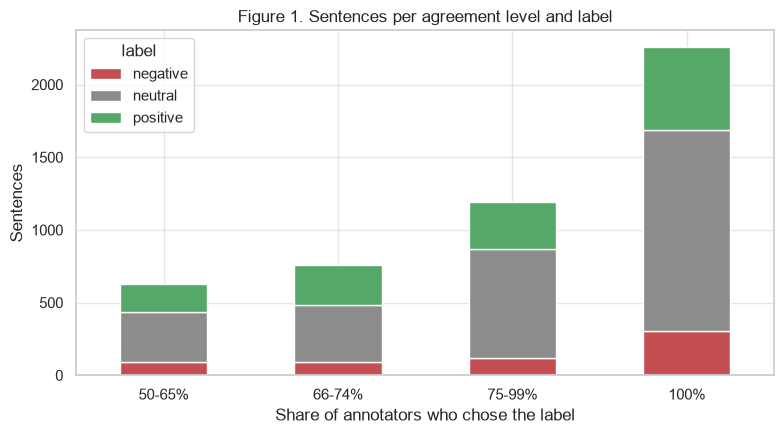

In [12]:
counts = pd.crosstab(sentences["agreement"], sentences["label"])[LABELS]
fig, ax = plt.subplots(figsize=(8, 4.5))
counts.plot.bar(stacked=True, ax=ax, rot=0, color=["C3", "C7", "C2"])
ax.set_title("Figure 1. Sentences per agreement level and label")
ax.set_xlabel("Share of annotators who chose the label")
ax.set_ylabel("Sentences")
ax.legend(title="label")
plt.tight_layout()
plt.show()

**Interpretation:** 2,871 sentences (59.4%) are neutral, 1,361 (28.1%) positive and only 604 (12.5%) negative. The stratified split keeps these shares within about one percentage point in all three splits. Figure 1 shows that the annotators fully agreed on 2,259 sentences (46.7%). Below 75% agreement 34.1% of the sentences are positive, with full agreement only 25.2%. A model that always answers "neutral" would be right on 58.9% of the test sentences, so accuracy alone says little.

In [13]:
# words with a "+" in front of a non-ASCII character are broken letters, for example "Sepp+ñl+ñ"
broken = sentences["sentence"].str.contains(r"\+[^\x00-\x7f]")
print(f"sentences with broken letters: {broken.sum()} ({broken.mean():.1%})")
print(sentences.loc[broken, "sentence"].str.extract(r"(\S*\+[^\x00-\x7f]\S*)")[0].head(6).tolist())

sentences with broken letters: 93 (1.9%)
['Sepp+ñl+ñ', 'Brand+úo', '+àland', 'L+ñnnen', 'Sepp+ñl+ñ', '+àland']


In [14]:
words = sentences["sentence"].str.split().str.len()
print(f"words per sentence: median {words.median():.0f}, shortest {words.min()}, longest {words.max()}")

numbers = sentences["sentence"].str.contains(r"\d")
print(f"sentences with at least one number: {numbers.mean():.1%}")

words per sentence: median 21, shortest 2, longest 81
sentences with at least one number: 53.3%


In [15]:
print(sentences.groupby("label")["sentence"].apply(lambda s: s.str.contains(r"\d").mean()).round(3))

label
negative    0.753
neutral     0.467
positive    0.577
Name: sentence, dtype: float64


93 sentences (1.9%) contain broken letters. `Sepp+ñl+ñ` is the Finnish name Seppälä and `+àland` is Åland, so a letter outside ASCII became a plus and another character. My guess is an old encoding error, UTF-8 text that was read once with a DOS code page. The frequent cases could be mapped back, but a few rare patterns do not give a clear letter. I keep all these sentences as they are, so the data has no mix of repaired and broken names. The broken words are mostly company and place names, not the words that carry the sentiment.

The sentences are short, a median of 21 words, the longest has 81. 75.3% of the negative sentences contain a number, against 46.7% of the neutral ones. That fits the examples above, many negative sentences report a fall of profit or sales in figures.

In [16]:
# the preparation keeps every template group in one split, I check this first
group_sizes = sentences["group"].value_counts()
splits_per_group = sentences.groupby("group")["split"].nunique()
print(f"Template groups with more than one sentence: {(group_sizes > 1).sum()}")
print(f"Template groups in more than one split: {(splits_per_group > 1).sum()}")

Template groups with more than one sentence: 123
Template groups in more than one split: 0


In [17]:
def closest_sentence(queries, pool):
    """Return the highest TF-IDF cosine similarity and the closest pool sentence for every query sentence."""
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)
    pool_vectors = vectorizer.fit_transform(sentences.loc[pool, "sentence"])
    query_vectors = vectorizer.transform(sentences.loc[queries, "sentence"])
    similarity = cosine_similarity(query_vectors, pool_vectors)
    return similarity.max(axis=1), sentences.index[pool][similarity.argmax(axis=1)]

In [18]:
# an exact twin is the same sentence once everything except the letters is removed
letters_only = sentences["sentence"].str.lower().str.replace(r"[^a-z]", "", regex=True)
is_train = sentences["split"] == "train"
is_validation = sentences["split"] == "validation"
is_test = sentences["split"] == "test"

checks = [("test against train and validation", is_test, ~is_test),
          ("validation against train", is_validation, is_train)]
closest = {}
for name, queries, pool in checks:
    exact_twins = letters_only[queries].isin(set(letters_only[pool])).sum()
    similarity, nearest = closest_sentence(queries, pool)
    closest[name] = similarity, nearest
    print(f"{name}: exact twins {exact_twins}, similarity >= 0.8: {(similarity >= 0.8).sum()}, "
          f"highest similarity {similarity.max():.2f}")

# the five closest pairs between test and the other two splits
similarity, nearest = closest["test against train and validation"]
# the index is the row number of the test sentence in the dataset
closest_pairs = pd.DataFrame({
    "similarity": similarity.round(2),
    "test sentence": sentences.loc[is_test, "sentence"].to_numpy(),
    "closest train or validation sentence": sentences.loc[nearest, "sentence"].to_numpy(),
}, index=sentences.index[is_test])
closest_pairs.sort_values("similarity", ascending=False).head(5)

test against train and validation: exact twins 0, similarity >= 0.8: 0, highest similarity 0.77
validation against train: exact twins 0, similarity >= 0.8: 0, highest similarity 0.78


,similarity,test sentence,closest train or validation sentence
173,0.77,"Both operating profit and turnover for the six-month period increased , respectively from EUR0 .1 m and EUR29 .0 m , as compared to the correspond...","Both operating profit and turnover for the nine-month period increased , respectively from EUR2 .4 m and EUR43 .8 m , as compared to the correspon..."
166,0.74,"Both operating profit and net sales for the six-month period increased , respectively from EUR18 .1 m and EUR127 .6 m , as compared to the corresp...","Both operating profit and net sales for the nine-month period increased , respectively by 26.6 % and 3.4 % , as compared to the corresponding peri..."
4594,0.72,Below are unaudited consolidated results for Aspocomp Group under IFRS reporting standards .,"Below are consolidated , unaudited results for Amanda Capital under IFRS reporting standards ."
4579,0.72,"Operating profit for the nine-month period decreased from EUR19 .9 m while net sales increased from EUR155 .7 m , as compared to the corresponding...","Operating profit for the nine-month period increased from EUR13 .6 m , while net sales increased from EUR394 .7 m , as compared to the correspondi..."
164,0.69,"Both operating profit and net sales for the six-month period increased , respectively , from EUR13 .8 m and EUR143 .6 m , as compared to the corre...","Both operating profit and net sales for the nine-month period increased , respectively by 26.6 % and 3.4 % , as compared to the corresponding peri..."


None of the 123 template groups is spread over two splits. No test sentence has an exact twin or a similarity of 0.8 or more in train or validation, and the same holds for validation against train. I fixed the 0.8 before I built the groups. The check fits the TF-IDF weights on the pool only, so its values are higher than in the preparation, which fits them on all sentences and groups from 0.65 on. Still, all five closest pairs are variants of a train or validation sentence with other figures or a few other words. So the grouping misses some templates, and the test results may be optimistic.

## Preprocessing for the model

The model reads token ids from the tokenizer of the pretrained encoder. The tokenizer lower-cases the text, removes accents and splits the words into word pieces, and it adds `[CLS]` at the start and `[SEP]` at the end. A `DataLoader` pads every batch to its longest sentence.

In [19]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, revision=MODEL_REVISION)
encoded = tokenizer(sentences["sentence"].tolist(), truncation=True, max_length=MAX_TOKENS)
sentences["tokens"] = [len(ids) for ids in encoded["input_ids"]]
# a sentence with exactly MAX_TOKENS tokens may have been cut
print(f"Sentences cut at {MAX_TOKENS} tokens: {(sentences['tokens'] >= MAX_TOKENS).sum()}")
sentences["tokens"].describe().round(1)

Sentences cut at 160 tokens: 0


count    4836.0
mean       30.6
std        13.6
min         4.0
25%        21.0
50%        28.0
75%        38.0
max       150.0
Name: tokens, dtype: float64

In [20]:
unknown = sum(ids.count(tokenizer.unk_token_id) for ids in encoded["input_ids"])
print(f"Vocabulary size: {tokenizer.vocab_size:,}")
print(f"Unknown tokens: {unknown}")

Vocabulary size: 30,522
Unknown tokens: 0


In [21]:
# the first sentence with broken letters, to see what the tokenizer makes of it
example = sentences.index[broken][0]
print(sentences.loc[example, "sentence"])
print(tokenizer.convert_ids_to_tokens(encoded["input_ids"][example]))

Clothing retail chain Sepp+ñl+ñ 's sales increased by 8 % to EUR 155.2 mn , and operating profit rose to EUR 31.1 mn from EUR 17.1 mn in 2004 .
['[CLS]', 'clothing', 'retail', 'chain', 'sep', '##p', '+', 'nl', '+', 'n', "'", 's', 'sales', 'increased', 'by', '8', '%', 'to', 'eu', '##r', '155', '.', '2', 'mn', ',', 'and', 'operating', 'profit', 'rose', 'to', 'eu', '##r', '31', '.', '1', 'mn', 'from', 'eu', '##r', '17', '.', '1', 'mn', 'in', '2004', '.', '[SEP]']


The median sentence has 28 tokens and the longest 150, so the limit of 160 never cuts a sentence. No token is unknown. The broken name `Sepp+ñl+ñ` becomes `sep`, `##p`, `+`, `nl`, `+`, `n`, because the uncased tokenizer also removes the accent from ñ. So the name is still there, only in small pieces. Amounts like `EUR 155.2 mn` also become several pieces, and the model has to learn from the context that they belong together.

In [22]:
def pad_batch(batch):
    """Pad a list of (token ids, label) items to the longest sentence of the batch.

    Returns the ids, the attention mask (1 for real tokens, 0 for padding) and the labels."""
    ids = nn.utils.rnn.pad_sequence([item[0] for item in batch], batch_first=True,
                                    padding_value=tokenizer.pad_token_id)
    mask = (ids != tokenizer.pad_token_id).long()
    labels = torch.stack([item[1] for item in batch])
    return ids, mask, labels


def make_loader(split, shuffle):
    """Build the DataLoader for one split ("train", "validation" or "test").

    The loader gets its own generator, so a shuffled order can be repeated with a seed."""
    index = np.flatnonzero(sentences["split"] == split)
    items = [(torch.tensor(encoded["input_ids"][i]), torch.tensor(int(sentences["label_id"].iat[i])))
             for i in index]
    generator = torch.Generator().manual_seed(MAIN_SEED)
    return DataLoader(items, batch_size=BATCH_SIZE, shuffle=shuffle, collate_fn=pad_batch,
                      generator=generator)

In [23]:
train_loader = make_loader("train", shuffle=True)
validation_loader = make_loader("validation", shuffle=False)
test_loader = make_loader("test", shuffle=False)
print(f"Batches: train {len(train_loader)}, validation {len(validation_loader)}, test {len(test_loader)}")

Batches: train 107, validation 23, test 23


In [24]:
# one validation batch, to check shapes and data types before the training
ids, mask, labels = next(iter(validation_loader))
print(f"Token ids: {tuple(ids.shape)}, {ids.dtype}")
print(f"Attention mask: {tuple(mask.shape)}, {mask.dtype}")
print(f"Labels: {tuple(labels.shape)}, {labels.dtype}")

Token ids: (32, 67), torch.int64
Attention mask: (32, 67), torch.int64
Labels: (32,), torch.int64


The training split gives 107 batches, validation and test 23 each, with up to 32 sentences per batch. The first validation batch is padded to 67 tokens, its longest sentence, and the mask marks the real tokens. The labels are integers, as `CrossEntropyLoss` expects.

## Reference model without deep learning

Before the Transformer I train a simple reference, a logistic regression on TF-IDF (Term Frequency - Inverse Document Frequency) features of words and word pairs. It shows how far word features alone get, so the Transformer has a floor to beat. I train it twice, with equal and with balanced class weights, the same idea as the weighted loss of the experiment. It is not part of the controlled comparison, and I evaluate it together with the Transformer in the evaluation section.

In [25]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
x_train = vectorizer.fit_transform(sentences.loc[is_train, "sentence"])
x_test = vectorizer.transform(sentences.loc[is_test, "sentence"])
y_train = sentences.loc[is_train, "label_id"]
print(f"TF-IDF features: {x_train.shape[1]:,}")
print(f"Training matrix: {x_train.shape[0]:,} x {x_train.shape[1]:,}, test matrix: {x_test.shape[0]:,} x {x_test.shape[1]:,}")

# the same reference twice, with equal and with balanced class weights
reference_predicted = {}
for class_weight in [None, "balanced"]:
    reference = LogisticRegression(max_iter=2000, class_weight=class_weight, random_state=MAIN_SEED)
    reference.fit(x_train, y_train)
    reference_predicted[class_weight] = reference.predict(x_test)

TF-IDF features: 11,338
Training matrix: 3,393 x 11,338, test matrix: 722 x 11,338


## Baseline model

The baseline is the pretrained encoder `distilbert-base-uncased` with a small classification head, fine-tuned end to end. DistilBERT keeps six of the twelve Transformer blocks of BERT and is fast enough on my CPU to train every configuration with five seeds. With only 3,393 training sentences a pretrained encoder makes more sense than an LSTM trained from scratch, because it brings language knowledge from a much larger corpus. I did not test an LSTM, so this is a reasoned choice, not a tested one. `transformers` provides DistilBERT, the model class, the head, the training loop and the evaluation are my own PyTorch code.

The head takes the `[CLS]` vector through a linear layer of 768 units, ReLU, dropout 0.1 and a second linear layer to three logits, one per class. The model returns logits because `CrossEntropyLoss` expects them.

Training uses AdamW with a learning rate of 2e-5, weight decay 0.01 and batch size 32, constant in both configurations. I train for 5 epochs, one more than usual for BERT, so the curves show when the model starts to overfit. I keep the weights of the epoch with the best validation macro-F1, not the lowest validation loss, because the unweighted loss could favor the baseline.

In [26]:
class SentenceClassifier(nn.Module):
    """Pretrained encoder with a small head on the [CLS] vector, one logit per class."""

    def __init__(self):
        """Load the pretrained encoder and build the head."""
        super().__init__()
        self.encoder = AutoModel.from_pretrained(MODEL_NAME, revision=MODEL_REVISION)
        hidden_size = self.encoder.config.hidden_size
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size, len(LABELS)),
        )

    def forward(self, ids, mask):
        """Return the logits, one row per sentence, the mask hides the padding from the encoder."""
        hidden = self.encoder(input_ids=ids, attention_mask=mask).last_hidden_state
        return self.head(hidden[:, 0])

In [27]:
set_seed(MAIN_SEED)
model = SentenceClassifier().to(device)
total = sum(p.numel() for p in model.parameters())
head_total = sum(p.numel() for p in model.head.parameters())
# the encoder is not frozen, so every parameter should be trainable
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {total / 1e6:.1f} M, encoder {(total - head_total) / 1e6:.1f} M, "
      f"head {head_total / 1e6:.2f} M")
print(f"Trainable parameters: {trainable:,} of {total:,}")
print(f"Attention heads per block: {model.encoder.config.n_heads}")
# PyTorch prints the six identical blocks as one entry
print(model)
del model

Parameters: 67.0 M, encoder 66.4 M, head 0.59 M
Trainable parameters: 66,955,779 of 66,955,779
Attention heads per block: 12
SentenceClassifier(
  (encoder): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((76

The model has 67.0 million parameters, 66.4 million in the encoder and 0.59 million in the head. All 66,955,779 are trainable, so the training changes the encoder as well as the head, in both configurations. The encoder starts with token embeddings of size 768 for 30,522 word pieces and learned position embeddings for 512 positions. Then come six blocks with the same structure, shown as `6 x TransformerBlock`, each with self-attention over 12 heads and a feed-forward part 768 to 3,072 to 768 with GELU, with dropout and a layer norm after both parts.